In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("Libraries loaded ✓")

Libraries loaded ✓


In [4]:
df = pd.read_excel('../data/online_retail.xlsx', engine='openpyxl')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 3 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [5]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Pct %': missing_pct})[missing > 0]

=== Missing Values ===


,Missing,Pct %
Description,1454,0.27
CustomerID,135080,24.93


In [6]:
print(f"Before cleaning: {df.shape}")

# Drop rows with no CustomerID (needed for customer analysis)
df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to int (removes decimal .0)
df['CustomerID'] = df['CustomerID'].astype(int)

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove bad quantity and price rows
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Add revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Parse date properly
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

print(f"After cleaning:  {df.shape}")
print(f"Rows removed:    {541909 - df.shape[0]:,}")
print(f"Date range:      {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique customers:{df['CustomerID'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")
print(f"Total revenue:   £{df['Revenue'].sum():,.2f}")

Before cleaning: (541909, 8)
After cleaning:  (397884, 11)
Rows removed:    144,025
Date range:      2010-12-01 → 2011-12-09
Unique customers:4,338
Unique products: 3,665
Total revenue:   £8,911,407.90


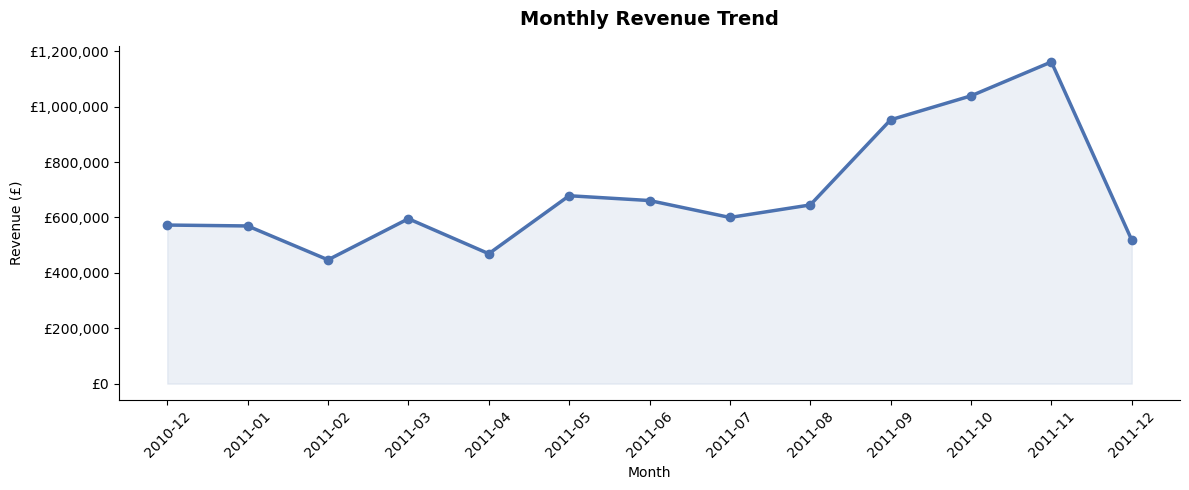

Saved ✓


In [7]:
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month_str'] = monthly['Month'].astype(str)

fig, ax = plt.subplots()
ax.plot(monthly['Month_str'], monthly['Revenue'], marker='o', linewidth=2.5, color='#4C72B0')
ax.fill_between(monthly['Month_str'], monthly['Revenue'], alpha=0.1, color='#4C72B0')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/01_monthly_revenue.png', dpi=150)
plt.show()
print("Saved ✓")

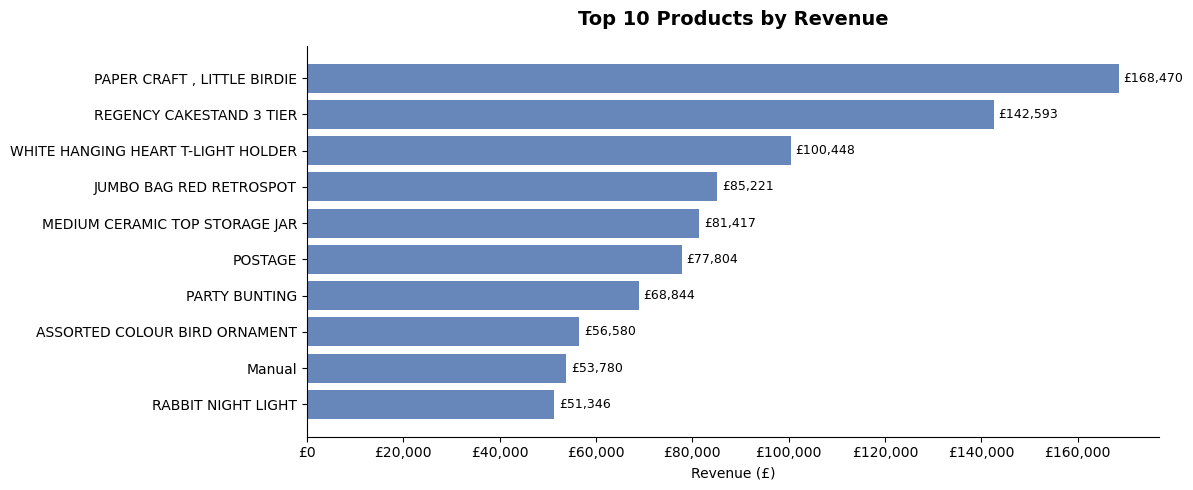

Saved ✓


In [8]:
top_products = (df.groupby('Description')['Revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

fig, ax = plt.subplots()
bars = ax.barh(top_products['Description'][::-1], 
               top_products['Revenue'][::-1], 
               color='#4C72B0', alpha=0.85)
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, top_products['Revenue'][::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/02_top_products.png', dpi=150)
plt.show()
print("Saved ✓")

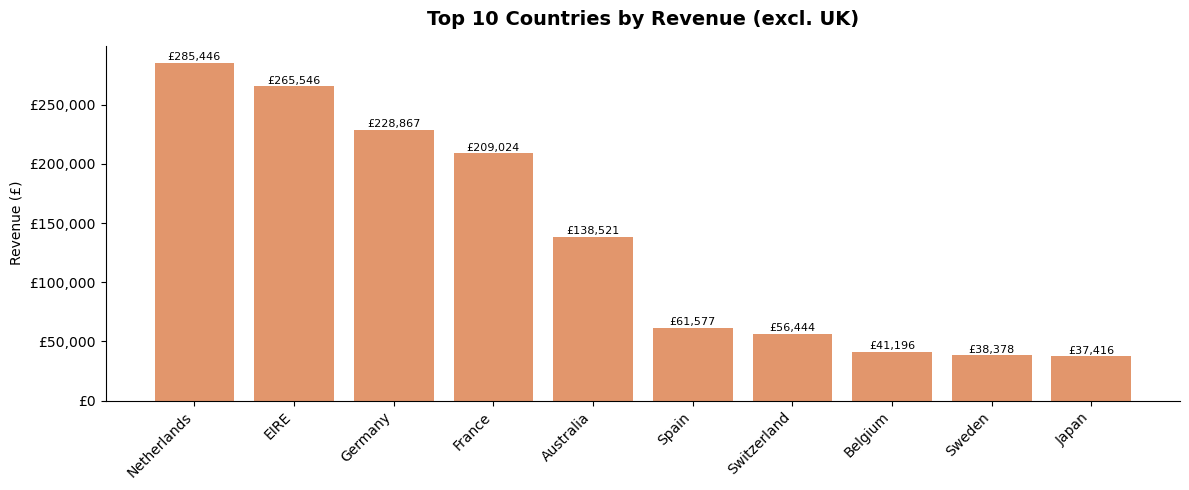

Saved ✓


In [9]:
top_countries = (df[df['Country'] != 'United Kingdom']
                 .groupby('Country')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

fig, ax = plt.subplots()
bars = ax.bar(top_countries['Country'], top_countries['Revenue'], 
              color='#DD8452', alpha=0.85)
ax.set_title('Top 10 Countries by Revenue (excl. UK)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, top_countries['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'£{val:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/03_top_countries.png', dpi=150)
plt.show()
print("Saved ✓")

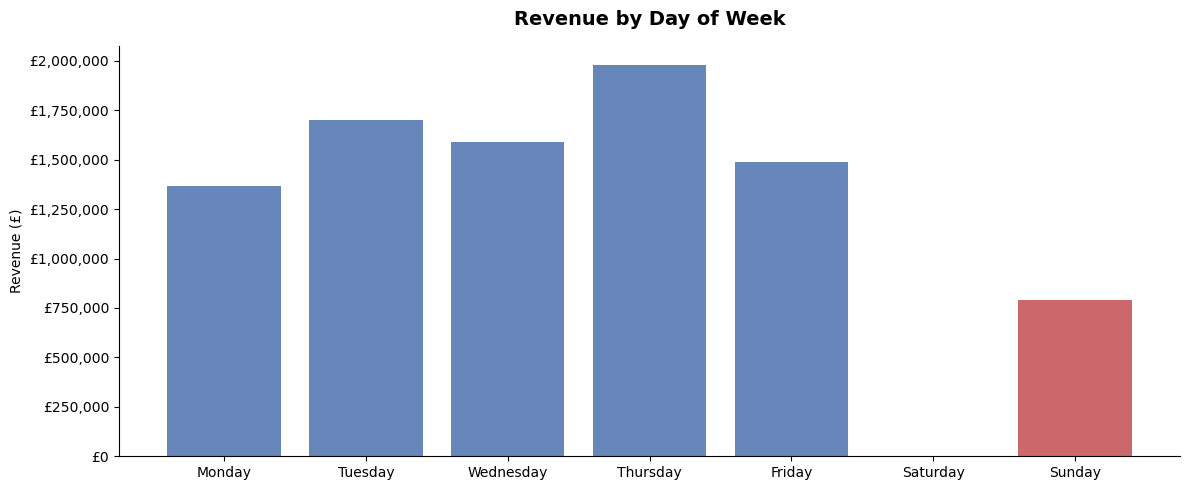

Saved ✓


In [10]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (df.groupby('DayOfWeek')['Revenue']
       .sum()
       .reindex(dow_order)
       .reset_index())

fig, ax = plt.subplots()
colors = ['#4C72B0' if d not in ['Saturday','Sunday'] else '#C44E52' for d in dow['DayOfWeek']]
ax.bar(dow['DayOfWeek'], dow['Revenue'], color=colors, alpha=0.85)
ax.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/04_day_of_week.png', dpi=150)
plt.show()
print("Saved ✓")

In [11]:
# Reference date = 1 day after last invoice
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(rfm.describe().round(2))

       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2054.27
std       1721.81   100.01       7.70    8989.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     307.41
50%      15299.50    51.00       2.00     674.48
75%      16778.75   142.00       5.00    1661.74
max      18287.00   374.00     209.00  280206.02


In [12]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])  # lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['Total_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r == 4 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r == 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r == 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

print(rfm['Segment'].value_counts())

Loyal Customers    1130
Lost               1084
At Risk            1066
Champions           799
Promising           185
New Customers        74
Name: Segment, dtype: int64


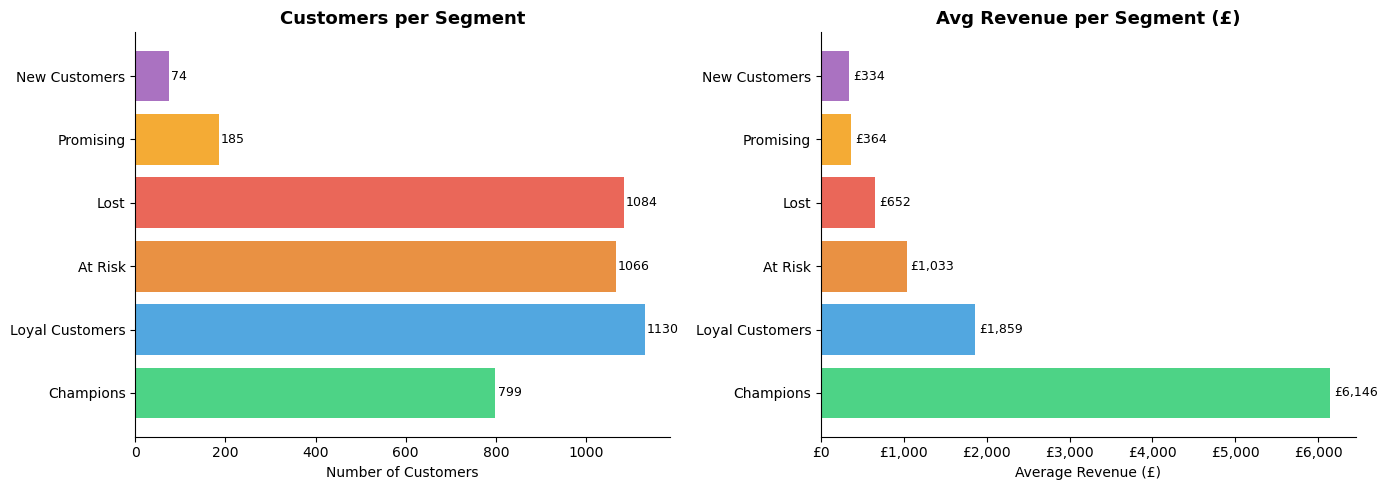

Saved ✓
        Segment  Customers  Avg_Revenue  Avg_Recency
      Champions        799  6146.493780     8.017522
Loyal Customers       1130  1858.552470    26.898230
        At Risk       1066  1032.703023    84.313321
           Lost       1084   652.415232   246.980627
      Promising        185   364.259243    34.075676
  New Customers         74   334.156622     9.635135


In [13]:
seg_summary = rfm.groupby('Segment').agg(
    Customers = ('CustomerID', 'count'),
    Avg_Revenue = ('Monetary', 'mean'),
    Avg_Recency = ('Recency', 'mean')
).reset_index().sort_values('Avg_Revenue', ascending=False)

colors_map = {
    'Champions':       '#2ecc71',
    'Loyal Customers': '#3498db',
    'New Customers':   '#9b59b6',
    'Promising':       '#f39c12',
    'At Risk':         '#e67e22',
    'Lost':            '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: customer count per segment
colors = [colors_map[s] for s in seg_summary['Segment']]
axes[0].barh(seg_summary['Segment'], seg_summary['Customers'], color=colors, alpha=0.85)
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for i, (val, seg) in enumerate(zip(seg_summary['Customers'], seg_summary['Segment'])):
    axes[0].text(val + 5, i, str(val), va='center', fontsize=9)

# Right: avg revenue per segment
axes[1].barh(seg_summary['Segment'], seg_summary['Avg_Revenue'], color=colors, alpha=0.85)
axes[1].set_title('Avg Revenue per Segment (£)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for i, val in enumerate(seg_summary['Avg_Revenue']):
    axes[1].text(val + 50, i, f'£{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/05_rfm_segments.png', dpi=150)
plt.show()
print("Saved ✓")
print(seg_summary.to_string(index=False))

MAE : £512.53
R²  : 0.597


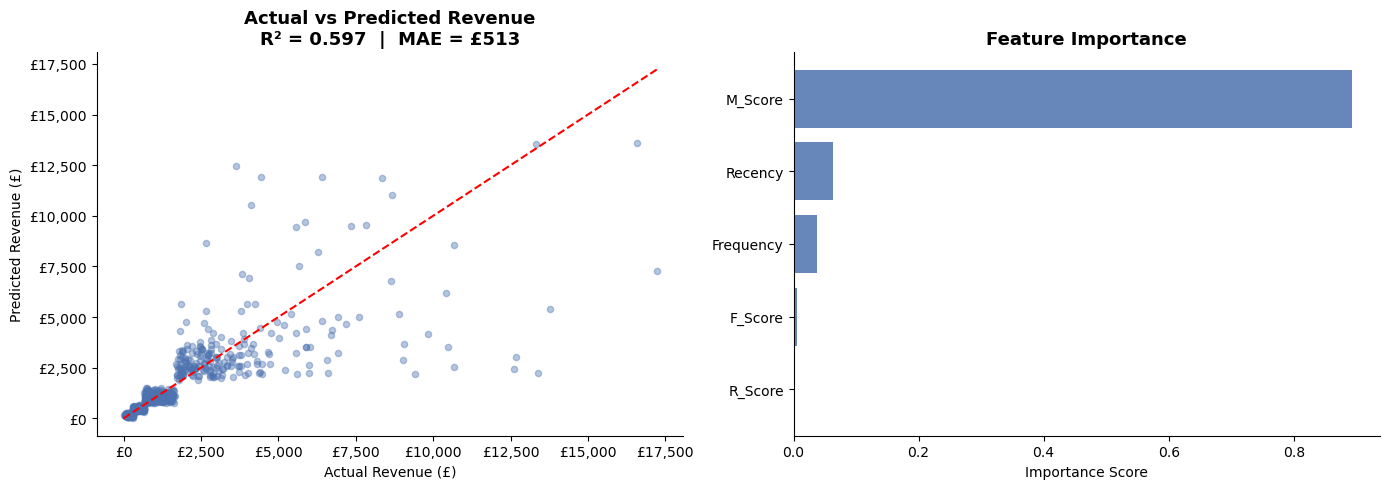

Saved ✓


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Log transform handles the extreme outliers
rfm_model = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)].copy()

X = rfm_model[['Recency', 'Frequency', 'R_Score', 'F_Score', 'M_Score']]
y = np.log1p(rfm_model['Monetary'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)

y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2  = r2_score(y_test_actual, y_pred_actual)

print(f"MAE : £{mae:,.2f}")
print(f"R²  : {r2:.3f}")

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_actual, y_pred_actual, alpha=0.4, color='#4C72B0', s=20)
max_val = max(y_test_actual.max(), y_pred_actual.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Revenue (£)')
axes[0].set_ylabel('Predicted Revenue (£)')
axes[0].set_title(f'Actual vs Predicted Revenue\nR² = {r2:.3f}  |  MAE = £{mae:,.0f}',
                  fontsize=13, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

axes[1].barh(feat_imp.index[::-1], feat_imp.values[::-1], color='#4C72B0', alpha=0.85)
axes[1].set_title('Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/06_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

In [15]:
total_rev       = df['Revenue'].sum()
champions_rev   = rfm[rfm['Segment']=='Champions']['Monetary'].sum()
at_risk_rev     = rfm[rfm['Segment']=='At Risk']['Monetary'].sum()
lost_rev        = rfm[rfm['Segment']=='Lost']['Monetary'].sum()
top_country     = df[df['Country']!='United Kingdom'].groupby('Country')['Revenue'].sum().idxmax()
top_product     = df.groupby('Description')['Revenue'].sum().idxmax()
peak_month      = monthly.loc[monthly['Revenue'].idxmax(), 'Month_str']

print("=" * 55)
print("         E-COMMERCE BUSINESS INSIGHTS SUMMARY")
print("=" * 55)
print(f"\n OVERVIEW")
print(f"  Total Revenue       : £{total_rev:>12,.2f}")
print(f"  Total Customers     : {df['CustomerID'].nunique():>12,}")
print(f"  Total Transactions  : {df['InvoiceNo'].nunique():>12,}")
print(f"  Total Products      : {df['StockCode'].nunique():>12,}")

print(f"\n CUSTOMER SEGMENTS")
for seg in ['Champions','Loyal Customers','At Risk','Lost','Promising','New Customers']:
    n   = rfm[rfm['Segment']==seg]['CustomerID'].count()
    rev = rfm[rfm['Segment']==seg]['Monetary'].sum()
    pct = rev / total_rev * 100
    print(f"  {seg:<18}: {n:>4} customers | £{rev:>10,.0f} ({pct:.1f}%)")

print(f"\n KEY FINDINGS")
print(f"  Peak sales month    : {peak_month}")
print(f"  Top international   : {top_country}")
print(f"  Top product         : {top_product}")
print(f"  Saturday revenue    : £0 (store closed)")
print(f"  Champions vs Lost   : {rfm[rfm['Segment']=='Champions']['Monetary'].mean() / rfm[rfm['Segment']=='Lost']['Monetary'].mean():.1f}x higher avg spend")

print(f"\n RECOMMENDATIONS")
print(f"  1. Re-engage {rfm[rfm['Segment']=='At Risk']['CustomerID'].count()} at-risk customers before they go lost")
print(f"  2. Expand Netherlands & EIRE — already outperforming Germany and France")
print(f"  3. Reward {rfm[rfm['Segment']=='Champions']['CustomerID'].count()} Champions — they drive disproportionate revenue")
print(f"  4. Investigate Saturday closure — potential revenue opportunity")
print("=" * 55)

         E-COMMERCE BUSINESS INSIGHTS SUMMARY

 OVERVIEW
  Total Revenue       : £8,911,407.90
  Total Customers     :        4,338
  Total Transactions  :       18,532
  Total Products      :        3,665

 CUSTOMER SEGMENTS
  Champions         :  799 customers | £ 4,911,049 (55.1%)
  Loyal Customers   : 1130 customers | £ 2,100,164 (23.6%)
  At Risk           : 1066 customers | £ 1,100,861 (12.4%)
  Lost              : 1084 customers | £   707,218 (7.9%)
  Promising         :  185 customers | £    67,388 (0.8%)
  New Customers     :   74 customers | £    24,728 (0.3%)

 KEY FINDINGS
  Peak sales month    : 2011-11
  Top international   : Netherlands
  Top product         : PAPER CRAFT , LITTLE BIRDIE
  Saturday revenue    : £0 (store closed)
  Champions vs Lost   : 9.4x higher avg spend

 RECOMMENDATIONS
  1. Re-engage 1066 at-risk customers before they go lost
  2. Expand Netherlands & EIRE — already outperforming Germany and France
  3. Reward 799 Champions — they drive disproporti